In [1]:
import pandas as pd
import sqlite3

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

pageviews = pd.io.sql.read_sql(
    """
    SELECT datetime
    FROM pageviews
    WHERE uid LIKE 'user_%'
    """,
    conn,
    parse_dates=['datetime']
)

conn.close()
pageviews.head()

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144


## Group by date and plot

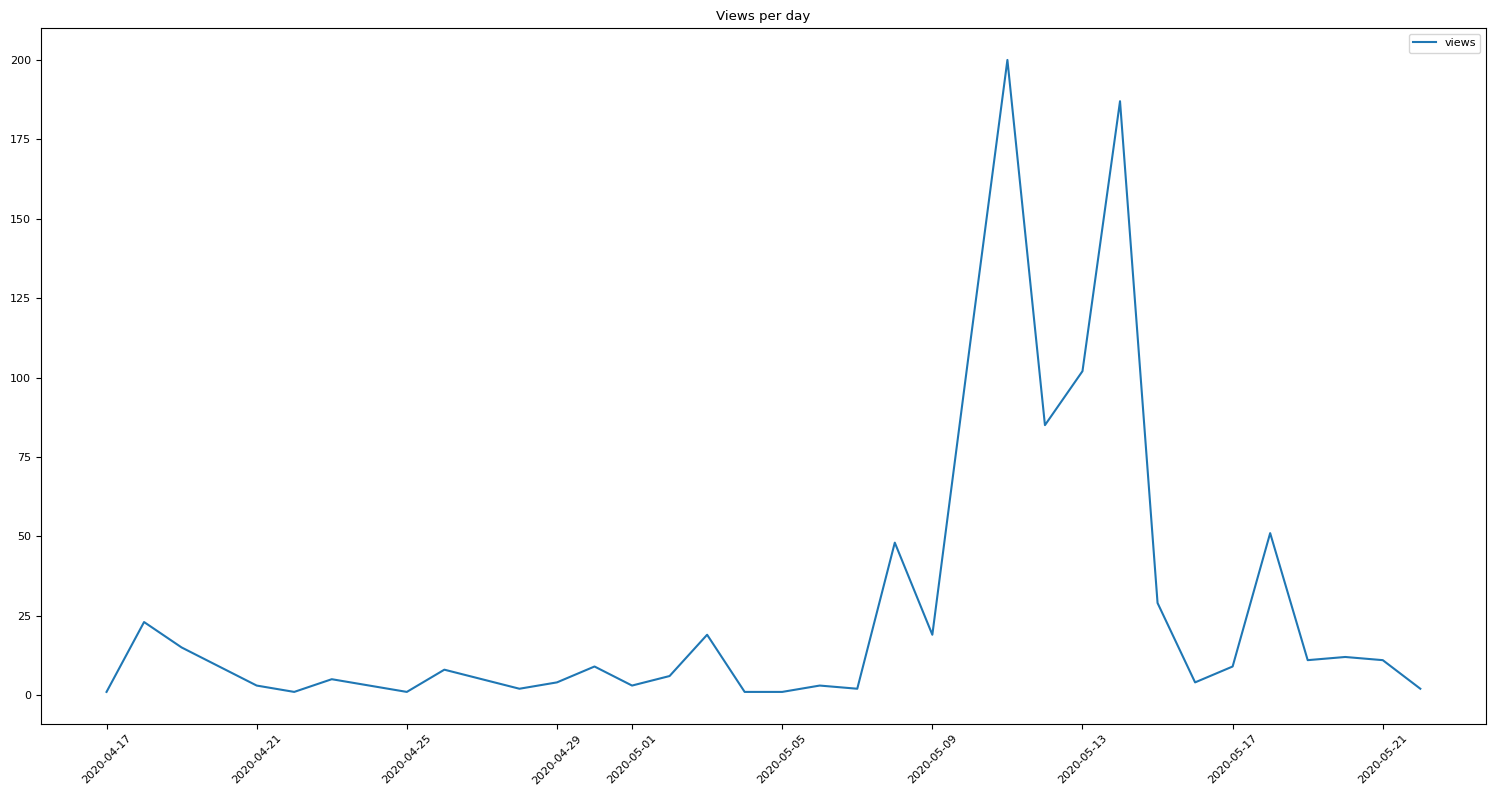

In [3]:
pageviews['date'] = pageviews['datetime'].dt.date
views_per_day = pageviews.groupby('date')['datetime'].count().reset_index()
views_per_day.columns = ['date', 'views']

import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 8
fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(views_per_day['date'], views_per_day['views'], label='views')
ax.set_title('Views per day')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()